# JupyterLite Python デモ

このノートはブラウザ上で動く JupyterLite（Pyodide） のデモです。上から順に実行してください。

- 初回は Python 環境のロードに時間がかかることがあります
- Pyodide の制約により、通常の Python と同じように pip install はできません
- numpy / pandas / matplotlib / scipy は動作することが多いです
- scikit-learn / statsmodels は環境によって動かない場合があるため、最後に任意として試します（失敗してもデモは成立します）


In [1]:
import sys
print(sys.version)
print("Hello JupyterLite!")


3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
Hello JupyterLite!


In [5]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("matplotlib", matplotlib.__version__)


numpy 1.26.4
pandas 2.2.2
matplotlib 3.9.2


In [6]:
x = np.linspace(0, 2*np.pi, 200)
y = np.sin(x)

df = pd.DataFrame({
 "x": x,
 "y": y,
})

df.head()


,x,y
0,0.000000,0.000000
1,0.031574,0.031569
2,0.063148,0.063106
3,0.094721,0.094580
4,0.126295,0.125960


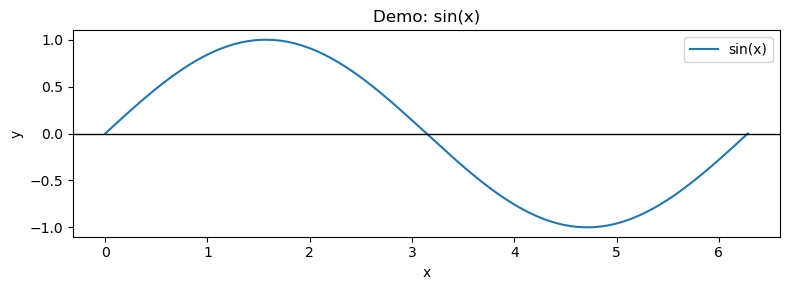

In [7]:
plt.figure(figsize=(8, 3))
plt.plot(df["x"], df["y"], label="sin(x)")
plt.axhline(0, color="black", linewidth=1)
plt.title("Demo: sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
df2 = df.copy()
df2["y2"] = df2["y"] ** 2

df2.describe()


,x,y,y2
count,200.000000,2.000000e+02,200.000000
mean,3.141593,0.000000e+00,0.497500
std,1.827466,7.071068e-01,0.355317
min,0.000000,-9.999688e-01,0.000000
25%,1.570796,-7.014869e-01,0.145087
50%,3.141593,-1.224647e-16,0.496054
75%,4.712389,7.014869e-01,0.849310
max,6.283185,9.999688e-01,0.999938


In [15]:
from scipy import optimize

f = lambda t: (t - 1.5)**2 + 0.3
res = optimize.minimize_scalar(f)

print("x* =", res.x)
print("f(x*) =", res.fun)


x* = 1.5
f(x*) = 0.3


## 任意（動けばラッキー）

ここから先は、環境によっては import できない可能性があるライブラリを試します。

エラーになっても『この JupyterLite では使えない』という判断で OK です。

In [12]:
try:
 import sklearn
 from sklearn.linear_model import LinearRegression

 X = df2[["x"]].to_numpy()
 yv = df2[["y"]].to_numpy()

 model = LinearRegression().fit(X, yv)
 print("sklearn version:", sklearn.__version__)
 print("coef:", model.coef_)
 print("intercept:", model.intercept_)

except Exception as e:
 print("scikit-learn is not available in this JupyterLite build.")
 print("Error:", e)


sklearn version: 1.8.0
coef: [[-0.29940947]]
intercept: [0.94062258]


In [13]:
try:
 import statsmodels.api as sm

 X = sm.add_constant(df2["x"])
 model = sm.OLS(df2["y"], X).fit()

 print(model.summary())

except Exception as e:
 print("statsmodels is not available in this JupyterLite build.")
 print("Error:", e)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                     295.5
Date:                Mon, 25 May 2026   Prob (F-statistic):           3.97e-41
Time:                        13:19:33   Log-Likelihood:                -122.65
No. Observations:                 200   AIC:                             249.3
Df Residuals:                     198   BIC:                             255.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9406      0.063     14.868      0.0

## 代替（sklearn が無くても動く）: NumPy で最小二乗回帰


In [14]:
A = np.c_[np.ones(len(df2)), df2[["x"]].to_numpy()]
yv = df2["y"].to_numpy()
coef, *_ = np.linalg.lstsq(A, yv, rcond=None)

intercept, slope = coef
print("intercept =", intercept)
print("slope =", slope)


intercept = 0.9406225811801058
slope = -0.29940946675734287


## 次に試すこと

- content/data/ に CSV を置いて読み込むデモにする（実データ体験）
- 可視化を散布図＋回帰線にする
- デモを複数ノート（01_..., 02_...）に分割して、難易度順に並べる
